In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import librosa
import os

In [19]:
df_preds = pd.read_csv('seniorTalk_predictions.csv')

In [20]:
df_preds.head(-30)

,id,height_true,height_pred,age_true,age_pred,gender_true,gender_pred
0,seniorTalk/sample_0,175.0,176.849136,81.0,29.453037,male,male
1,seniorTalk/sample_1,175.0,176.849136,81.0,29.453037,male,male
2,seniorTalk/sample_2,175.0,176.849136,81.0,29.453037,male,male
3,seniorTalk/sample_3,175.0,176.849136,81.0,29.453037,male,male
4,seniorTalk/sample_4,175.0,176.849136,81.0,29.453037,male,male
...,...,...,...,...,...,...,...
5834,seniorTalk/sample_5834,175.0,176.849136,77.0,29.453037,male,male
5835,seniorTalk/sample_5835,175.0,176.849136,77.0,29.453037,male,male
5836,seniorTalk/sample_5836,175.0,176.849136,77.0,29.453037,male,male
5837,seniorTalk/sample_5837,175.0,176.849136,77.0,29.453037,male,male


In [21]:
df_preds['error'] = df_preds['age_pred'] - df_preds['age_true']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['age_pred'] - df_preds['age_true']).mean()
MSE = ((df_preds['age_pred'] - df_preds['age_true'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['age_pred'] - df_preds['age_true']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     47.924 лет
RMSE (Root Mean Squared Error): 47.938 лет
Std of Error (разброс ошибок):  1.189 лет

Процент ошибок в пределах:
  ≤ 1 год:   0.0%
  ≤ 3 года:  0.0%
  ≤ 5 лет:   0.0%
  ≤ 10 лет:   0.0%

Статистика абсолютных ошибок:
  Мин ошибка:  46.547 лет
  Медиана:     47.547 лет
  Макс ошибка: 51.547 лет


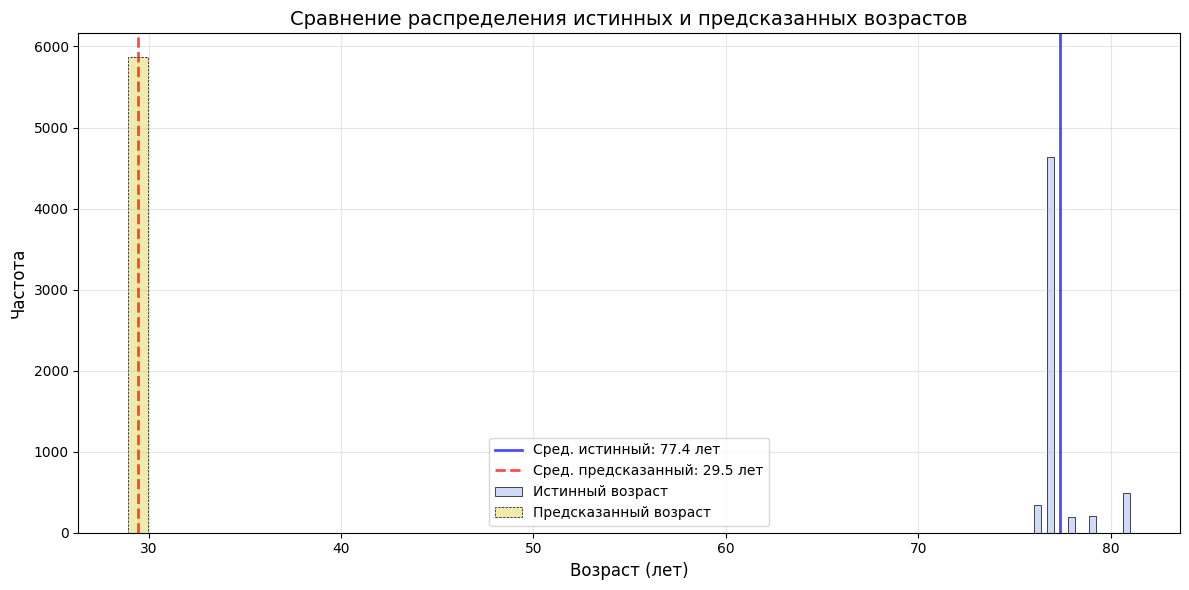

In [22]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='age_true', 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='age_pred',
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['age_true'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["age_true"].mean():.1f} лет')
plt.axvline(df_preds['age_pred'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["age_pred"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()